# Helper Functions

Using data from v29

changes from v29:
- no bvp and ibi (no ablation test)
- more granular sweep
- Added Cross Correlation

In [2]:
from pathlib import Path

INPUT_BASE = Path("/kaggle/input/notebooks/alecy333/glycemic-copy/")
if not INPUT_BASE.exists():
    INPUT_BASE = Path("/kaggle/input/datasets/alecy333/glycemia-processed")
    if not INPUT_BASE.exists():
        print("No notebook input detected... using working output directory.")
        INPUT_BASE = Path("/kaggle/working")


print(INPUT_BASE)

No notebook input detected... using working output directory.
/kaggle/working


In [3]:
import warnings
import pandas as pd
import numpy as np
from pathlib import Path
warnings.filterwarnings("ignore")

BASE = Path(
    "/kaggle/input/datasets/alecy333/big-ideas-glycemic-1-13/big-ideas-lab-glycemic-variability-and-wearable-device-data-1.1.3"
)

food3_cols = ['date', 'time', 'time_begin', 'logged_food', 'amount',
       'unit', 'searched_food', 'calorie', 'total_carb', 'dietary_fiber',
       'sugar', 'protein', 'total_fat']

# ---> FIX 1: Pass the global_t0 into the function <---
def to_relative_minutes(df, global_t0, time_col="Timestamp"):
    df = df.copy()
    df["minutes"] = (df[time_col] - global_t0).dt.total_seconds() / 60.0
    return df


def load_dexcom(pid: str) -> pd.DataFrame:
    fpath = BASE / pid / f"Dexcom_{pid}.csv"
    df = pd.read_csv(fpath, low_memory=False)
    df = df.rename(columns={
        "Timestamp (YYYY-MM-DDThh:mm:ss)": "Timestamp",
        "Glucose Value (mg/dL)":           "Glucose",
        "Event Type":                       "EventType"
    })
    df = df[df["EventType"] == "EGV"].copy()
    df["Timestamp"] = pd.to_datetime(df["Timestamp"], errors="coerce")
    df["Glucose"]   = pd.to_numeric(df["Glucose"], errors="coerce")
    df = df.dropna(subset=["Timestamp", "Glucose"])
    df = df[["Timestamp", "Glucose"]].sort_values("Timestamp").reset_index(drop=True)
    # ---> FIX 2: Removed local relative minute conversion <---
    return df


def load_wearable(pid: str, signal: str) -> pd.DataFrame:
    fpath = BASE / pid / f"{signal}_{pid}.csv"
    if not fpath.exists():
        print(f"  WARNING: {fpath.name} not found")
        return None
    df = pd.read_csv(fpath)
    df.columns = df.columns.str.strip()
    df = df.rename(columns={"datetime": "Timestamp"})
    df["Timestamp"] = pd.to_datetime(df["Timestamp"], errors="coerce")
    df = df.dropna(subset=["Timestamp"]).sort_values("Timestamp").reset_index(drop=True)
    # ---> FIX 3: Removed local relative minute conversion <---
    return df

def load_participant(pid: str) -> dict:
    data = {}
    
    # 1. Load all raw data first
    data["Dexcom"] = load_dexcom(pid)
    for signal in ["EDA", "HR", "TEMP", "ACC", "BVP", "IBI"]:
        result = load_wearable(pid, signal)
        if result is not None:
            data[signal] = result
            
    # ---> FIX 4: Find the absolute Global t0 across all loaded devices <---
    t0_candidates = []
    for key, df in data.items():
        if df is not None and not df.empty and "Timestamp" in df.columns:
            #print(f"{key}: min={df['Timestamp'].min()}, dtype={df['Timestamp'].dtype}, nans={df['Timestamp'].isna().sum()}")
            t0_candidates.append(df["Timestamp"].min())
            
    global_t0 = min(t0_candidates) # The absolute earliest moment recording started
    
    # Apply the global_t0 to all physiological dataframes
    for key, df in data.items():
        if df is not None and not df.empty and "Timestamp" in df.columns:
            data[key] = to_relative_minutes(df, global_t0)
    # ----------------------------------------------------------------------
    
    # Food log
    food_path = BASE / pid / f"Food_Log_{pid}.csv"
    if food_path.exists():
        try:
            if pid == '003':
                food = pd.read_csv(food_path, names=food3_cols, header=None)
            else:            
                food = pd.read_csv(food_path)
            food.columns = food.columns.str.strip()
            
            if "time_begin" in food.columns:
                time_col = "time_begin"
            elif "time" in food.columns:
                time_col = "time"
            else:
                time_col = None
            
            if time_col:
                food[time_col] = pd.to_datetime(food[time_col], errors="coerce")
                # ---> FIX 5: Use the newly established global_t0 <---
                food["food_minutes"] = (food[time_col] - global_t0).dt.total_seconds() / 60.0
            
            data["Food"] = food
        except Exception as e:
            print(f"  Food log warning for {pid}: {e}")
    
    return data

In [4]:
def resample_to_1min(df, value_col, mask_below=None):
    """
    Convert irregular signal into 1-min averaged time series.
    ONLY produces signal-level representation (no feature engineering).
    """
    df = df.copy()

    if mask_below is not None:
        df.loc[df[value_col] < mask_below, value_col] = np.nan

    df["minute_bin"] = df["minutes"].astype(int)

    # ONLY MEAN (important simplification)
    resampled = df.groupby("minute_bin")[value_col].mean()

    return resampled


def build_minute_grid(d):
    """
    FIXED TO BE VECTORIZED NOW
    Unified 1-minute aligned dataset.
    Each column = raw physiological signal (NOT engineered features).
    """
    max_min = int(d["Dexcom"]["minutes"].max())

    grid = pd.DataFrame({"minute": np.arange(0, max_min + 1)})
    grid = grid.set_index("minute")

    # --- RECONSTRUCT GLOBAL T0 ---
    dexcom_first_timestamp = d["Dexcom"]["Timestamp"].min()
    dexcom_first_minute    = d["Dexcom"]["minutes"].min()
    global_t0 = dexcom_first_timestamp - pd.Timedelta(minutes=dexcom_first_minute)

    start_minutes_from_midnight = global_t0.hour * 60 + global_t0.minute
    grid["minutes_from_midnight"] = (start_minutes_from_midnight + grid.index) % 1440

    # --- PHYSIOLOGICAL SIGNALS ---
    gluc = (
        resample_to_1min(d["Dexcom"], "Glucose")
        .reindex(grid.index)
        .interpolate(method="linear", limit=15)
    )
    grid["glucose"] = gluc
    grid["hr"]   = resample_to_1min(d["HR"],   "hr")
    grid["eda"]  = resample_to_1min(d["EDA"],  "eda")
    grid["temp"] = resample_to_1min(d["TEMP"], "temp", mask_below=25)
    grid["bvp"]  = resample_to_1min(d["BVP"],  "bvp")
    grid["ibi"]  = resample_to_1min(d["IBI"],  "ibi")

    acc = d["ACC"].copy()
    acc["magnitude"] = np.sqrt(acc["acc_x"]**2 + acc["acc_y"]**2 + acc["acc_z"]**2)
    grid["acc"] = resample_to_1min(acc, "magnitude")

    # --- MEAL FEATURES (vectorized) ---
    grid["is_postprandial"] = 0
    grid["time_since_meal"] = 999.0
    grid["meal_event"]      = 0
    grid["carbs"]           = 0.0
    grid["sugar"]           = 0.0
    grid["protein"]         = 0.0
    grid["calories"]        = 0.0

    if "Food" in d and not d["Food"].empty:
        food_df = d["Food"]

        # 1. Filter to valid rows that fall within the grid
        valid = (
            food_df
            .dropna(subset=["food_minutes"])
            .copy()
        )
        valid["minute"] = valid["food_minutes"].astype(int)
        valid = valid[valid["minute"].isin(grid.index)]

        if not valid.empty:
            # 2. Macro accumulation — group by minute, sum everything in one shot
            #    fillna(0) handles rows where a macro column is missing
            macro_agg = (
                valid
                .assign(
                    total_carb=valid["total_carb"].fillna(0),
                    sugar=valid["sugar"].fillna(0),
                    protein=valid["protein"].fillna(0),
                    calorie=valid["calorie"].fillna(0),
                )
                .groupby("minute")
                .agg(
                    meal_event=("minute",    "count"),
                    carbs=     ("total_carb","sum"),
                    sugar=     ("sugar",     "sum"),
                    protein=   ("protein",   "sum"),
                    calories=  ("calorie",   "sum"),
                )
            )
            # Clip meal_event to binary and write back
            macro_agg["meal_event"] = 1
            grid.update(macro_agg)

            # 3. is_postprandial and time_since_meal — vectorized scan
            #    For each minute in the grid, find the most recent meal at or before it
            meal_minutes = np.sort(valid["minute"].unique())
            grid_idx     = grid.index.values  # numpy array, fast

            # searchsorted gives the index of the meal just before or at each grid minute
            pos = np.searchsorted(meal_minutes, grid_idx, side="right") - 1

            # pos == -1 means no meal has happened yet
            has_prior_meal = pos >= 0

            # time since the most recent meal
            last_meal_at = np.where(has_prior_meal, meal_minutes[np.maximum(pos, 0)], -999)
            time_since   = np.where(has_prior_meal, grid_idx - last_meal_at, 999)

            grid["time_since_meal"]  = time_since
            grid["is_postprandial"]  = ((time_since >= 0) & (time_since <= 120)).astype(int)

    # Cap time_since_meal at 180 min (assumes return to fasting baseline)
    grid["time_since_meal"] = grid["time_since_meal"].clip(upper=180)

    return grid

#personalized labels
# def build_labels_only(grid, prediction_horizon=30, std_multiplier=1.0, window_mins=1440, min_baseline_mins=360, stride=5):
#     # 1. The Trailing Baseline (Strictly PAST data, no leakage)
#     rolling_mean = grid['glucose'].rolling(window=window_mins, min_periods=min_baseline_mins).mean()
#     rolling_std  = grid['glucose'].rolling(window=window_mins, min_periods=min_baseline_mins).std()
    
#     dynamic_threshold = rolling_mean + (rolling_std * std_multiplier)
    
#     # 2. The Target Event (Strictly FUTURE data)
#     if prediction_horizon > 0:
#         window_size = int(prediction_horizon + 1)
#         forward_max = grid['glucose'].iloc[::-1].rolling(
#             window=window_size, 
#             min_periods=1
#         ).max().iloc[::-1]
#     else:
#         forward_max = grid['glucose']
        
#     # 3. Create the binary label
#     labels = (forward_max > dynamic_threshold).astype(int)
    
#     # 4. Clean up (Drop rows where we are still building the initial baseline)
#     valid_mask = labels.notna() & grid['glucose'].notna() & dynamic_threshold.notna()
    
#     records = pd.DataFrame({
#         "minute": grid.index[valid_mask],
#         "label": labels[valid_mask].values,
#         "current_glucose": grid.loc[valid_mask, 'glucose'].values,
#         "future_max_glucose": forward_max[valid_mask].values,
#         "dynamic_threshold": dynamic_threshold[valid_mask].values
#     })
    
#     # 5. THE STRIDE: Apply the decimation right before returning
#     # iloc[::stride] simply takes every Nth row.
#     records = records[records["minute"] % stride == 0].reset_index(drop=True)
    
#     return records

def build_labels_only(grid, prediction_horizon=30, rise_threshold=30, stride=5, min_future_points=3):
    """
    Hard Threshold (Non personalized). FIXED TO BE VECTORIZED. 
    Scans the grid and returns a dataframe of labels mapped to the exact minute.
    Vectorized: uses a reverse rolling max instead of a Python for-loop.
    """
    glucose = grid["glucose"]

    # forward_max[t] = max glucose in [t, t + prediction_horizon]
    # Achieved by reversing the series, rolling, then reversing back
    forward_max = (
        glucose[::-1]
        .rolling(window=prediction_horizon + 1, min_periods=min_future_points)
        .max()
        [::-1]
    )

    rise = forward_max - glucose

    labels = pd.DataFrame({
        "minute":           grid.index,
        "label":            (rise >= rise_threshold).astype(int),
        "rise_mg_dl":       rise,
        "future_max":       forward_max,
    })

    # Drop rows where glucose or future window was insufficient
    labels = labels.dropna(subset=["rise_mg_dl"])

    # Apply stride
    labels = labels[labels["minute"] % stride == 0].reset_index(drop=True)

    # Drop the last prediction_horizon minutes — the rolling window there
    # is right-padded with NaNs so forward_max underestimates the true future.
    # (The dropna above handles most of this, but be explicit.)
    max_valid_minute = grid.index.max() - prediction_horizon
    labels = labels[labels["minute"] <= max_valid_minute].reset_index(drop=True)

    return labels

In [5]:
def build_feature_matrix(grid, labels_df, tau=0, physio_windows=[120], food_windows=[120, 480, 1440]):
    """
    1. Shifts and rolls the perfect 1-minute grid.
    2. Merges with the sparse labels_df.
    """
    # Create a copy so we don't modify the cached master grid
    df = grid.copy()
    out = pd.DataFrame(index=df.index)

    #add physiological features
    modalities = {"hr": "hr", "eda": "eda", "temp": "temp", "acc": "acc", "bvp": "bvp", "ibi": "ibi"}

    for w in physio_windows:
        for mod, col in modalities.items():
            lag = tau if isinstance(tau, int) else tau.get(mod, 0)
            
            # Because 'df' is exactly 1-min spaced, shift(lag) correctly shifts by 'lag' minutes
            shifted = df[col].shift(lag)
            
            # Rolling over window_size minutes

            tolerance = 0.8
            min_req = int(tolerance*w)
            r = shifted.rolling(window=w, min_periods=min_req)
    
            out[f"{mod}_mean_{w}m"] = r.mean()
            out[f"{mod}_std_{w}m"]  = r.std()
            out[f"{mod}_max_{w}m"]  = r.max()
            
            # Slope calculation
            # slope = (value_at_t  -  value_at_(t - w + 1)) / (w - 1)
            end_val   = shifted  # the current value is the last in the window
            start_val = shifted.shift(w - 1)  # the first value in the window
            out[f"{mod}_slope_{w}m"] = (end_val - start_val) / (w - 1)

    blinding_lag = tau if isinstance(tau, int) else min(tau.values()) #heuristic lag added to nonphysiological features to prevent data leakage

    #add food columns
    food_cols = ["meal_event", "carbs", "sugar", "protein", "calories"]
    for col in food_cols:
        if col in df.columns:
            shifted = df[col].shift(blinding_lag)
            
            for w in food_windows:
                # min_periods=1 is crucial here! 
                # If we used 3, a single meal event surrounded by zeros would yield NaN.
                r = shifted.rolling(w, min_periods=1)
                
                if col == "meal_event":
                    out[f"Eatcnt_{w}m"] = r.sum()
                else:
                    out[f"{col}_{w}m"] = r.sum()

    #contextual columns
    context_cols = ["minutes_from_midnight", "is_postprandial", "time_since_meal"]
    for c in context_cols:
        if c in df.columns:
            out[c] = df[c].shift(blinding_lag)
            
    out = out.reset_index() # Pulls 'minute' out of the index to a column

    # MERGE: Only keep rows where we have a calculated label from our stride=5 process
    final_df = pd.merge(labels_df, out, on="minute", how="inner")
    
    # Drop rows where feature generation failed (e.g., due to the lag/window pushing into NaNs)
    feature_cols = [c for c in final_df.columns if c not in ["minute", "label", "rise_mg_dl"]]
    final_df = final_df.dropna(how="all", subset=feature_cols)

    return final_df

In [6]:
def create_master_data(prediction_horizon, exclude=[]):
    ALL_PIDS = [f"{i:03d}" for i in range(1, 17)]
    master_data = {} 
    
    for pid in ALL_PIDS:
        if pid in exclude:
            continue
        
        print(f"Processing {pid}...", end=" ")
        try:
            # 1. Load raw data and build the continuous 1-minute baseline
            grid_path = INPUT_BASE / f"{pid}_grid.csv"
            
            if grid_path.exists():
                grid = pd.read_csv(grid_path, index_col="minute")
            else:
                dp   = load_participant(pid)
                grid = build_minute_grid(dp)
                grid.to_csv(f"{pid}_grid.csv")
    
            # 2. Build ONLY the sparse targets (stride=5)
            # FIX: Dynamically name the cache file based on the horizon to prevent cross-contamination
            label_filename = f"{pid}_labels_h{prediction_horizon}.csv"
            labels_path = INPUT_BASE / label_filename
            
            if labels_path.exists():
                labels_df = pd.read_csv(labels_path)
            else:
                labels_df = build_labels_only(grid, prediction_horizon=prediction_horizon, rise_threshold=30)
                labels_df["pid"] = pid
                # Write to current working directory using the specific horizon filename
                labels_df.to_csv(label_filename, index=False)
            
            # 3. Store BOTH pieces in the master cache
            master_data[pid] = {
                "grid": grid,
                "labels": labels_df
            }      
            
            print(f"{len(labels_df)} samples, {labels_df['label'].mean():.1%} positive")
            
        except Exception as e:
            print(f"FAILED — {e}")

    return master_data

In [7]:
def build_full_dataset(master_data, tau=0, physio_windows=[120], food_windows=[120,480,1440], save_csv=True, filename=None, verbose=False):
    """
    Build feature-engineered dataset from master_data.

    Parameters
    ----------
    master_data : dict
        pid -> dictionary containing "grid" (continuous 1-min data) 
               and "labels" (sparse targets)

    tau : int or dict
        physiological lag
        tau could be a single int, or a dict of dicts

    window_size : int
        window length in minutes

    Returns
    -------
    full_dataset : pd.DataFrame
    """

    feature_tables = []

    for pid, data_dict in master_data.items():
        
        # 1. Unpack the decoupled grid and labels for this participant
        grid = data_dict["grid"]
        labels_df = data_dict["labels"]

        lags = tau if isinstance(tau, int) else tau.get(pid, {}) #if tau is a dict of pid:dict of lags, grab the corresponding lag dict.
        
        # 2. Pass both into the updated feature matrix builder
        feat_df = build_feature_matrix(
            grid=grid,
            labels_df=labels_df,
            tau=lags,
            physio_windows=physio_windows,
            food_windows=food_windows
        )

        idx = int(pid)

        patient_row = demo_df[demo_df["ID"] == idx]
        if not patient_row.empty:
            hba1c_val = patient_row["HbA1c"].values[0]
            gender_str = str(patient_row["Gender"].values[0]).strip().upper()
            
            feat_df["hba1c"] = hba1c_val
            feat_df["sex"] = 1 if gender_str == "MALE" else 0
        else:
            # Fallback if a patient is missing from the demographics file
            feat_df["hba1c"] = np.nan
            feat_df["sex"] = np.nan
        feat_df["pid"] = pid

        feature_tables.append(feat_df)

    full_dataset = pd.concat(
        feature_tables,
        ignore_index=True
    )

    if save_csv:
        if filename is None:
            if isinstance(tau, dict):
                filename = "full_dataset_modality_lag.csv"
            else:
                filename = f"full_dataset_tau_{tau}.csv"

        full_dataset.to_csv(filename, index=False)

    if verbose:
        print(f"\nTotal samples: {len(full_dataset):,}")
        print(
            f"Participants: "
            f"{full_dataset['pid'].nunique()}"
        )
        print(
            f"Overall positive: "
            f"{full_dataset['label'].mean():.1%}"
        )
    
        print(
            full_dataset.groupby("pid")["label"]
            .agg(["count", "mean"])
            .rename(
                columns={
                    "count": "samples",
                    "mean": "pos_rate"
                }
            )
            .round(3)
            .to_string()
        )

    return full_dataset

In [8]:
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE

def run_loso(dataset, feature_cols, model, scale=True, verbose=False, smote=False):
    """
    dataset:
        concatenated feature dataframe
        already contains engineered features

    model:
        sklearn-style estimator supporting
        fit() and predict_proba()

    feature_cols:
        columns to use as predictors
    """

    all_pids = dataset["pid"].unique()

    y_true_all = []
    y_prob_all = []
    per_pid_auc = {}

    fold_importances = np.zeros(len(feature_cols))
    all_importances = []
    
    for test_pid in all_pids:
        if verbose:
            print(f"Leave one out -- test_pid for this iteration: {test_pid}")
        train = dataset[dataset["pid"] != test_pid]
        test  = dataset[dataset["pid"] == test_pid]

        train = train.dropna(subset=feature_cols)
        test  = test.dropna(subset=feature_cols)

        if verbose:
            print(f"Train set length: {len(train)}")
            print(f"Test set length: {len(test)}")
        
        if len(train) == 0 or len(test) == 0:
            print("no valid train or test set")
            print(f"length of train: {len(train)}")
            print(f"length of test: {len(train)}")
            continue

        X_train = train[feature_cols].values
        y_train = train["label"].values
        X_test = test[feature_cols].values
        y_test = test["label"].values

        if isinstance(model, XGBClassifier):
            ratio = (y_train == 0).sum() / (y_train == 1).sum()
            model.set_params(scale_pos_weight=ratio)

        if y_train.sum() >= 6 and smote:
            sm = SMOTE(random_state=42, k_neighbors=5)
            X_train, y_train = sm.fit_resample(X_train, y_train)
            if verbose:
                print(f"Smote used. New dataset size: {len(X_train)}")
                print(f"New positive ratio: {(y_train == 0).sum() / len(y_train)}")
                
        if scale:
            scaler = StandardScaler()
            X_train = scaler.fit_transform(X_train)
            X_test = scaler.transform(X_test)

        model.fit(X_train, y_train)

        all_importances.append(model.feature_importances_)
        
        y_prob = model.predict_proba(X_test)[:, 1]

        # if test_pid == "015":
        #     print(f"\n--- DEEP DIVE PATIENT 015 ---")
        #     print(f"Total Test Rows: {len(y_test)}")
        #     print(f"True Spikes (y_test sum): {y_test.sum()}")
        #     print(f"Predicted Probs for Spikes: {y_prob[y_test == 1]}")
        #     print("-----------------------------\n")

        y_true_all.extend(y_test)
        y_prob_all.extend(y_prob)

        if len(np.unique(y_test)) > 1:
            per_pid_auc[test_pid] = roc_auc_score(
                y_test,
                y_prob
            )
    
    return (
        np.array(y_true_all),
        np.array(y_prob_all),
        per_pid_auc,
        all_importances
    )

# Data Loading and Preprocessing

In [9]:
demo_df = pd.read_csv("/kaggle/input/datasets/alecy333/big-ideas-glycemic-1-13/big-ideas-lab-glycemic-variability-and-wearable-device-data-1.1.3/Demographics.csv")
demo_df = demo_df.sort_values(by="ID")
demo_df.reset_index(drop=True)

,ID,Gender,HbA1c
0,1,FEMALE,5.5
1,2,MALE,5.6
2,3,FEMALE,5.9
3,4,FEMALE,6.4
4,5,FEMALE,5.7
5,6,FEMALE,5.8
6,7,FEMALE,5.3
7,8,FEMALE,5.6
8,9,MALE,6.1
9,10,FEMALE,6.0


In [10]:
#build feature columns
FEATURE_COLS = []
demographics = ["sex", "hba1c"]
FEATURE_COLS.extend(demographics)
context_cols = ["minutes_from_midnight", "is_postprandial", "time_since_meal"]
food_cols = ["meal_event", "carbs", "sugar", "protein", "calories"]

FEATURE_COLS.extend(context_cols)

physio_windows = [15, 30, 120, 360] #changed to shorter windows  
food_windows = [120, 480, 1440] #from Bent 2021

modalities = {"hr": "hr", "eda": "eda", "temp": "temp", "acc": "acc", "ibi": "ibi", "bvp": "bvp"}
#f"{mod}_mean_{w}m"

physio_cols = []

for w in physio_windows:
    for mod in modalities.keys():
        physio_cols.append(f"{mod}_mean_{w}m")
        physio_cols.append(f"{mod}_std_{w}m")
        physio_cols.append(f"{mod}_max_{w}m")
        physio_cols.append(f"{mod}_slope_{w}m")
FEATURE_COLS.extend(physio_cols)

food_feats = []

for w in food_windows:
    for col in food_cols:
        if col == "meal_event":
            food_feats.append(f"Eatcnt_{w}m")
        else:
            food_feats.append(f"{col}_{w}m")

FEATURE_COLS.extend(food_feats)

print(FEATURE_COLS)
print(f"Number of Features: {len(FEATURE_COLS)}")

['sex', 'hba1c', 'minutes_from_midnight', 'is_postprandial', 'time_since_meal', 'hr_mean_15m', 'hr_std_15m', 'hr_max_15m', 'hr_slope_15m', 'eda_mean_15m', 'eda_std_15m', 'eda_max_15m', 'eda_slope_15m', 'temp_mean_15m', 'temp_std_15m', 'temp_max_15m', 'temp_slope_15m', 'acc_mean_15m', 'acc_std_15m', 'acc_max_15m', 'acc_slope_15m', 'ibi_mean_15m', 'ibi_std_15m', 'ibi_max_15m', 'ibi_slope_15m', 'bvp_mean_15m', 'bvp_std_15m', 'bvp_max_15m', 'bvp_slope_15m', 'hr_mean_30m', 'hr_std_30m', 'hr_max_30m', 'hr_slope_30m', 'eda_mean_30m', 'eda_std_30m', 'eda_max_30m', 'eda_slope_30m', 'temp_mean_30m', 'temp_std_30m', 'temp_max_30m', 'temp_slope_30m', 'acc_mean_30m', 'acc_std_30m', 'acc_max_30m', 'acc_slope_30m', 'ibi_mean_30m', 'ibi_std_30m', 'ibi_max_30m', 'ibi_slope_30m', 'bvp_mean_30m', 'bvp_std_30m', 'bvp_max_30m', 'bvp_slope_30m', 'hr_mean_120m', 'hr_std_120m', 'hr_max_120m', 'hr_slope_120m', 'eda_mean_120m', 'eda_std_120m', 'eda_max_120m', 'eda_slope_120m', 'temp_mean_120m', 'temp_std_120m',

In [11]:
print("Creating the master dictionary...")
master_data = create_master_data(prediction_horizon=30) #NO prediction horizon. predict EXACTLY at time t. 

Creating the master dictionary...
Processing 001... 2557 samples, 3.6% positive
Processing 002... 2114 samples, 6.2% positive
Processing 003... 2297 samples, 3.6% positive
Processing 004... 2161 samples, 3.6% positive
Processing 005... 2553 samples, 2.4% positive
Processing 006... 2840 samples, 5.6% positive
Processing 007... 2202 samples, 3.2% positive
Processing 008... 2508 samples, 5.1% positive
Processing 009... 2301 samples, 4.6% positive
Processing 010... 2145 samples, 8.0% positive
Processing 011... 2839 samples, 4.6% positive
Processing 012... 2169 samples, 4.5% positive
Processing 013... 1972 samples, 6.5% positive
Processing 014... 2233 samples, 6.2% positive
Processing 015... 1673 samples, 2.3% positive
Processing 016... 2274 samples, 6.1% positive


In [12]:
for pid, data in master_data.items():
    food = data["grid"]["meal_event"].sum()
    spikes = master_data[pid]["labels"]["label"].sum()
    print(f"{pid}: meal_events={food:.0f}, spikes={spikes:.0f}")

001: meal_events=44, spikes=92
002: meal_events=49, spikes=132
003: meal_events=29, spikes=83
004: meal_events=24, spikes=78
005: meal_events=44, spikes=62
006: meal_events=46, spikes=159
007: meal_events=36, spikes=71
008: meal_events=30, spikes=128
009: meal_events=52, spikes=106
010: meal_events=76, spikes=172
011: meal_events=45, spikes=131
012: meal_events=83, spikes=98
013: meal_events=59, spikes=129
014: meal_events=40, spikes=138
015: meal_events=46, spikes=39
016: meal_events=22, spikes=138


# Experiment A -- ZERO LAG BASELINE

## Create the Zero Lag Baseline Dataframe

In [14]:
print("Building dataset (tau = 0)...")
filename = "full_data_exp_a_h15.csv"
no_lag_full_path = INPUT_BASE / filename

if no_lag_full_path.exists():
    print("path exists, loading cached data...")
    full_data_no_lag = pd.read_csv(no_lag_full_path)
else:
    print("creating full labeled dataset...")
    full_data_no_lag = build_full_dataset(
        master_data,
        tau=0,
        physio_windows=physio_windows,
        food_windows=food_windows,
        filename=filename,
        verbose=True
    )

print(f"[INFO] Dataset shape: {full_data_no_lag.shape}")
print(f"[INFO] Positive rate: {full_data_no_lag['label'].mean():.3f}")
print(f"[INFO] Participants: {full_data_no_lag['pid'].nunique()}")

missing = [c for c in FEATURE_COLS if c not in full_data_no_lag.columns]
print(f"\n[CHECK] Missing features: {missing}")

full_data_no_lag

Building dataset (tau = 0)...
creating full labeled dataset...

Total samples: 36,838
Participants: 16
Overall positive: 4.8%
     samples  pos_rate
pid                   
001     2557     0.036
002     2114     0.062
003     2297     0.036
004     2161     0.036
005     2553     0.024
006     2840     0.056
007     2202     0.032
008     2508     0.051
009     2301     0.046
010     2145     0.080
011     2839     0.046
012     2169     0.045
013     1972     0.065
014     2233     0.062
015     1673     0.023
016     2274     0.061
[INFO] Dataset shape: (36838, 121)
[INFO] Positive rate: 0.048
[INFO] Participants: 16

[CHECK] Missing features: []


,minute,label,rise_mg_dl,future_max,pid,hr_mean_15m,hr_std_15m,hr_max_15m,hr_slope_15m,eda_mean_15m,...,protein_480m,protein_1440m,calories_120m,calories_480m,calories_1440m,minutes_from_midnight,is_postprandial,time_since_meal,hba1c,sex
0,115,0,7.4,68.0,001,77.304156,8.991288,97.498833,-1.289333,0.264320,...,0.0,0.0,0.0,0.0,0.0,1043,0,180,5.5,0
1,120,0,9.2,68.0,001,76.316278,5.508860,85.161500,0.745321,0.481799,...,0.0,0.0,0.0,0.0,0.0,1048,0,180,5.5,0
2,125,0,9.8,68.0,001,76.262100,6.945471,87.831833,0.427167,0.527685,...,0.0,0.0,0.0,0.0,0.0,1053,0,180,5.5,0
3,130,0,8.2,68.0,001,77.906967,7.493576,87.831833,0.376976,0.995639,...,0.0,0.0,0.0,0.0,0.0,1058,0,180,5.5,0
4,135,0,9.4,73.2,001,76.180511,6.801139,87.831833,-0.719393,1.329848,...,0.0,0.0,0.0,0.0,0.0,1063,0,180,5.5,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36833,11515,0,0.0,132.0,016,NaN,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,564,0,180,5.5,1
36834,11520,0,0.0,131.2,016,NaN,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,569,0,180,5.5,1
36835,11525,0,0.0,126.4,016,NaN,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,574,0,180,5.5,1
36836,11530,0,0.0,118.6,016,NaN,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,579,0,180,5.5,1


In [39]:
def perform_analysis(model, features, data, trial_name=""):
    print("\n Running LOSO-CV...")

    y_true_all, y_prob_all, per_pid_auc, all_importances = run_loso(
        data,
        features,
        model,
        verbose=True,
        scale=True
    )
    
    y_pred = (y_prob_all >= 0.5).astype(int)
    
    print(f"\n================ {trial_name} RESULTS ================")
    print(f"AUROC (overall): {roc_auc_score(y_true_all, y_prob_all):.3f}")
    
    print("\nPer-participant AUROC:")
    for pid, auc in per_pid_auc.items():
        print(f"  {pid}: {auc:.3f}")
    
    print(f"\nMean AUROC: {np.mean(list(per_pid_auc.values())):.3f}")
    print(f"Std AUROC:  {np.std(list(per_pid_auc.values())):.3f}")

    y_true_all, y_prob_all, per_pid_auc, all_importances, y_pred

## Random Forest Test

In [16]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, classification_report

print("\n==============================")
print("EXPERIMENT A.1 — RANDOM FOREST ZERO LAG MODEL")
print("==============================")

# ─────────────────────────────────────────────
# Model
# ─────────────────────────────────────────────
rfmodel = RandomForestClassifier(
    n_estimators=100,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

# ─────────────────────────────────────────────
# LOSO evaluation
# ─────────────────────────────────────────────
print("\n Running LOSO-CV...")
y_true_all, y_prob_all, per_pid_auc, all_importances = run_loso(
    full_data_no_lag,
    FEATURE_COLS,
    rfmodel,
    scale=True,
    verbose=True,
    smote=False
)

# ─────────────────────────────────────────────
# Results
# ─────────────────────────────────────────────

#y_pred = (y_prob_all >= 0.5).astype(int)

print("\n================ A.1 RESULTS ================")
print(f"AUROC (overall): {roc_auc_score(y_true_all, y_prob_all):.3f}")

print("\nPer-participant AUROC:")
for pid, auc in per_pid_auc.items():
    print(f"  {pid}: {auc:.3f}")

print(f"\nMean AUROC: {np.mean(list(per_pid_auc.values())):.3f}")
print(f"Std AUROC:  {np.std(list(per_pid_auc.values())):.3f}")


EXPERIMENT A.1 — RANDOM FOREST ZERO LAG MODEL

 Running LOSO-CV...
Leave one out -- test_pid for this iteration: 001
Train set length: 5434
Test set length: 515
Leave one out -- test_pid for this iteration: 002
Train set length: 4920
Test set length: 1029
Leave one out -- test_pid for this iteration: 003
Train set length: 5756
Test set length: 193
Leave one out -- test_pid for this iteration: 004
Train set length: 5709
Test set length: 240
Leave one out -- test_pid for this iteration: 005
Train set length: 5772
Test set length: 177
Leave one out -- test_pid for this iteration: 006
Train set length: 5826
Test set length: 123
Leave one out -- test_pid for this iteration: 007
Train set length: 5277
Test set length: 672
Leave one out -- test_pid for this iteration: 008
Train set length: 5442
Test set length: 507
Leave one out -- test_pid for this iteration: 009
Train set length: 5710
Test set length: 239
Leave one out -- test_pid for this iteration: 010
Train set length: 5732
Test set len

## Feature Selection

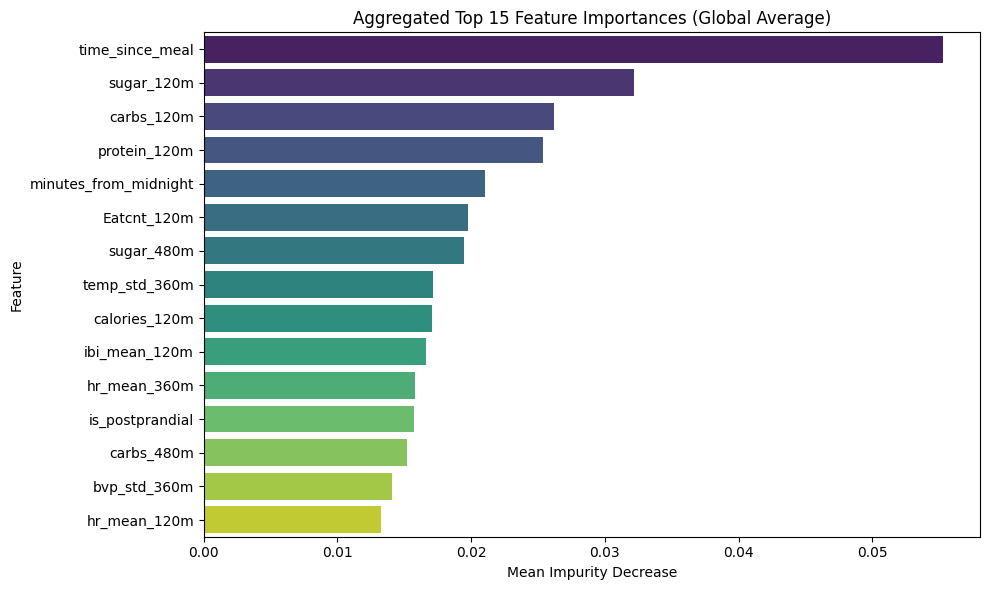

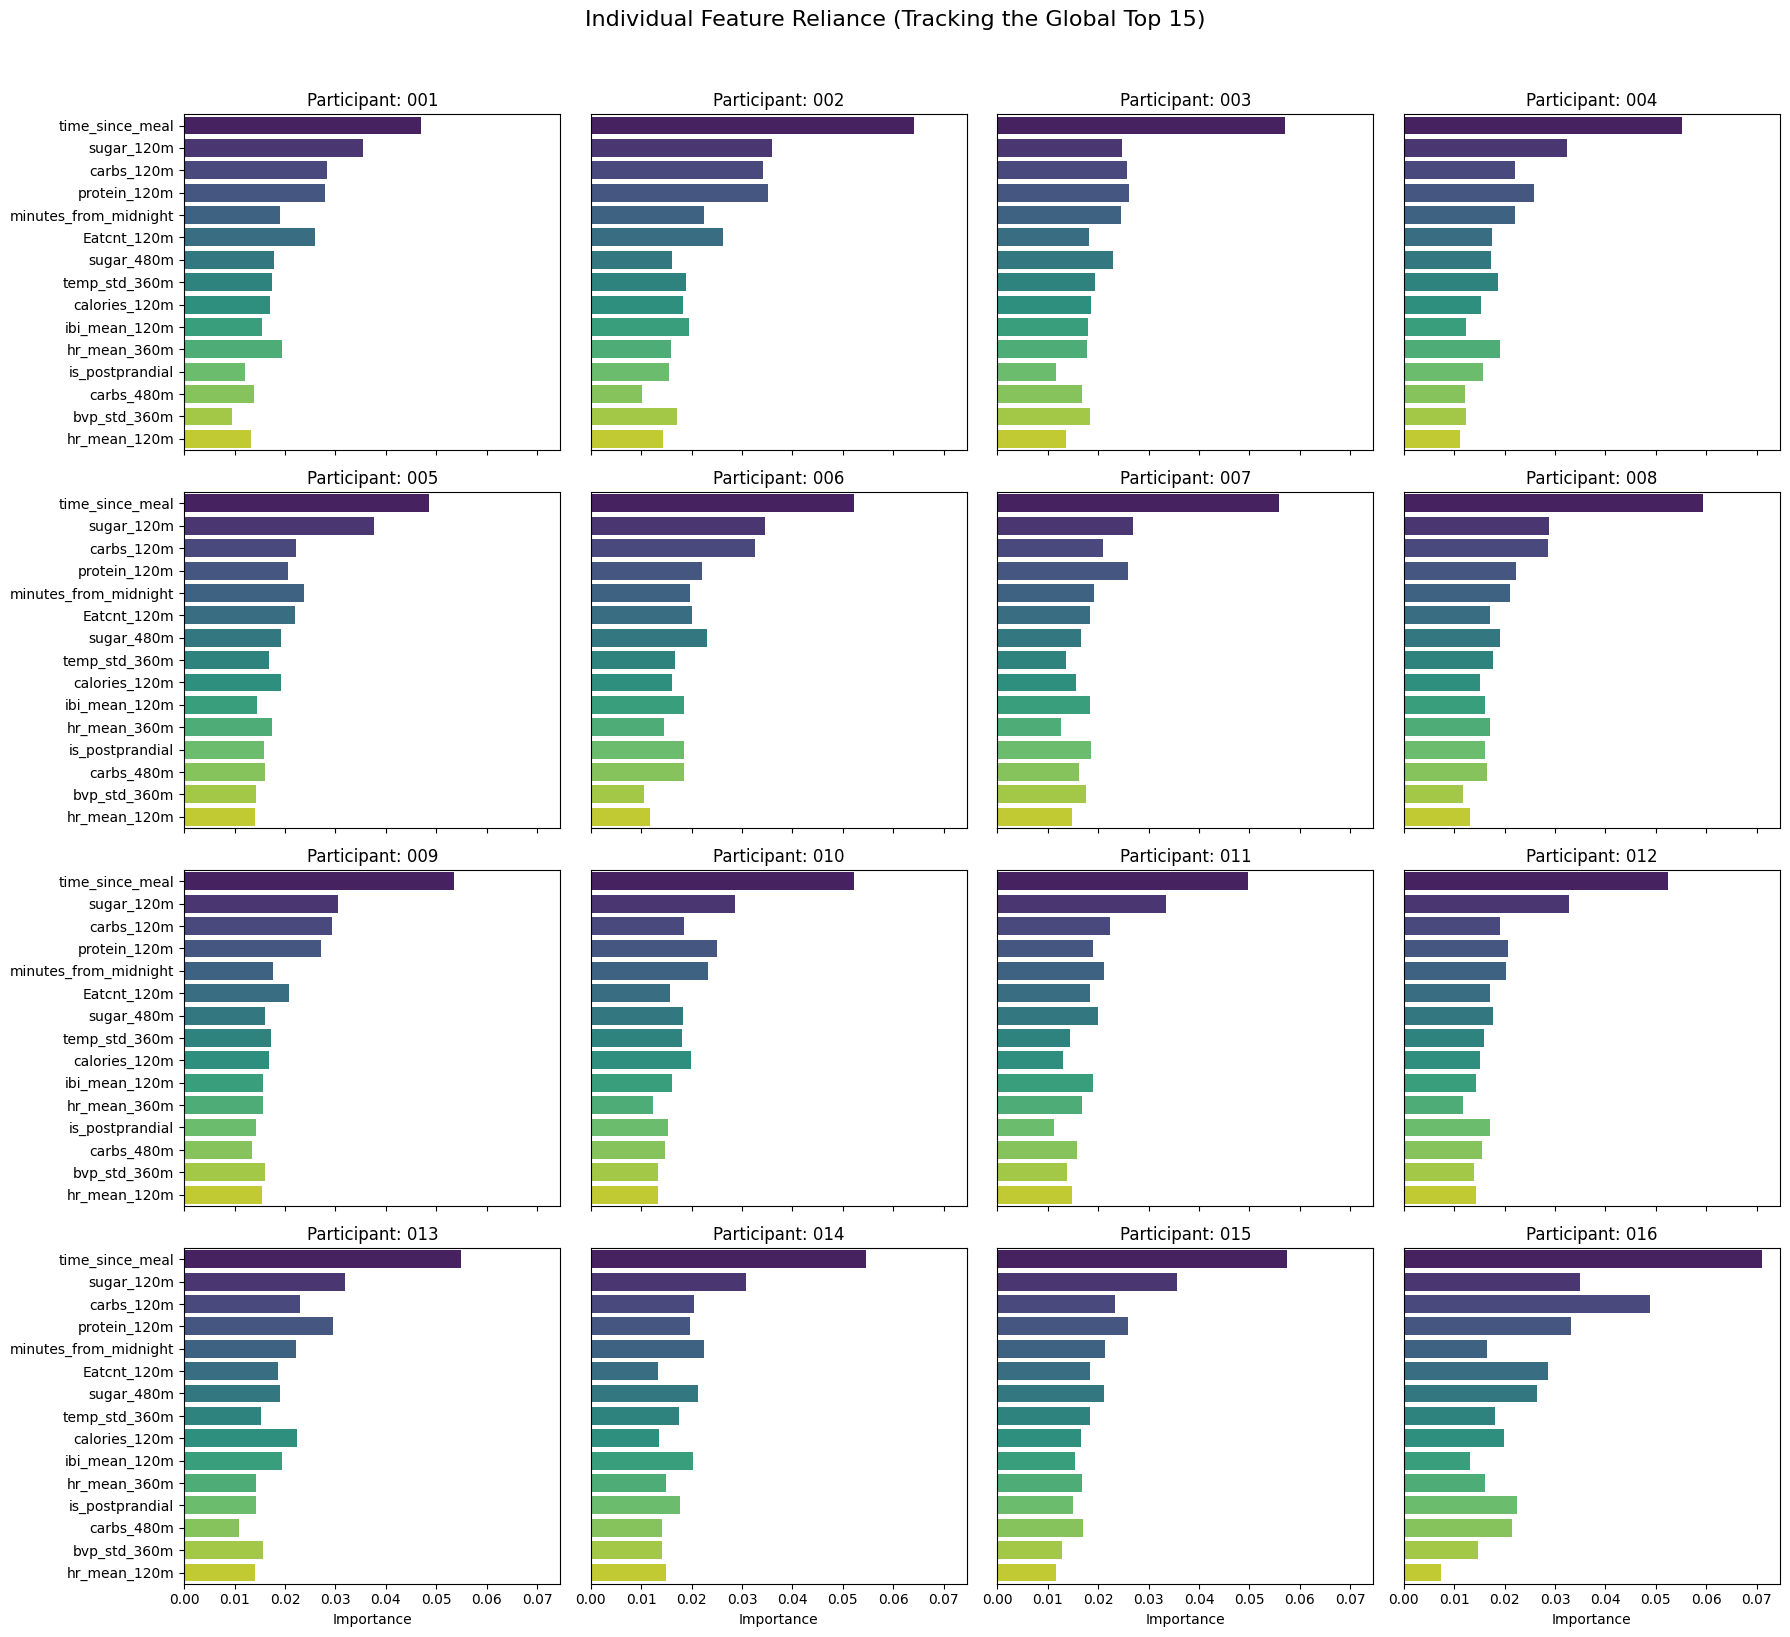

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import math

all_pids = full_data_no_lag["pid"].unique()
avg_importances = np.sum(all_importances, axis=0)/len(all_pids)

# --- 1. IDENTIFY THE GLOBAL TOP FEATURES ---
# Create a dataframe of the aggregated importances
global_importance_df = pd.DataFrame({
    'Feature': FEATURE_COLS,
    'Global_Importance': avg_importances
}).sort_values(by='Global_Importance', ascending=False)

# Get the names and original indices of the Top 15 features
top_n = 15
top_features = global_importance_df['Feature'].head(top_n).tolist()
top_indices = [FEATURE_COLS.index(f) for f in top_features]


# --- 2. PLOT THE AGGREGATED (GLOBAL) IMPORTANCES ---
plt.figure(figsize=(10, 6))
sns.barplot(
    data=global_importance_df.head(top_n), 
    x='Global_Importance', 
    y='Feature', 
    palette='viridis'
)
plt.title(f"Aggregated Top {top_n} Feature Importances (Global Average)")
plt.xlabel("Mean Impurity Decrease")
plt.tight_layout()
plt.show()


# --- 3. PLOT THE INDIVIDUAL GRID (APPLES-TO-APPLES) ---
num_pids = len(all_pids)
cols = 4
rows = math.ceil(num_pids / cols)

fig, axes = plt.subplots(rows, cols, figsize=(cols * 4.5, rows * 4), sharex=True)
axes = axes.flatten()

for i, (pid, importances) in enumerate(zip(all_pids, all_importances)):
    # Extract the scores for ONLY the global top 15 features
    individual_scores = [importances[idx] for idx in top_indices]
    
    sns.barplot(x=individual_scores, y=top_features, ax=axes[i], palette='viridis')
    axes[i].set_title(f"Participant: {pid}")
    axes[i].set_xlabel("Importance")
    
    # Hide Y-axis labels on the inner plots to keep the grid clean and tight
    if i % cols != 0:
        axes[i].set_ylabel("")
        axes[i].set_yticks([])

# Clean up any empty subplots if you have a number of pids that doesn't divide by 4 perfectly
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle(f"Individual Feature Reliance (Tracking the Global Top {top_n})", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

In [18]:
#copied this from one of the below cells
useless_features = global_importance_df.tail(20)["Feature"].tolist()

FEATURE_COLS_RF = [f for f in FEATURE_COLS if f not in useless_features]
print(len(FEATURE_COLS_RF))

96


### Test Feature-Selected Forest

In [19]:
print("\n==============================")
print("EXPERIMENT A.1.1 — RANDOM FOREST ZERO LAG MODEL, FEATURE-SELECTED")
print("==============================")

# ─────────────────────────────────────────────
# Model
# ─────────────────────────────────────────────
rfmodel = RandomForestClassifier(
    n_estimators=100,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

# ─────────────────────────────────────────────
# LOSO evaluation
# ─────────────────────────────────────────────
print("\n Running LOSO-CV...")

y_true_all, y_prob_all, per_pid_auc, all_importances = run_loso(
    full_data_no_lag,
    FEATURE_COLS_RF,
    rfmodel,
    verbose=True,
    scale=True
)

# ─────────────────────────────────────────────
# Results
# ─────────────────────────────────────────────

y_pred = (y_prob_all >= 0.5).astype(int)

print("\n================ A.1.1 RESULTS ================")
print(f"AUROC (overall): {roc_auc_score(y_true_all, y_prob_all):.3f}")

print("\nPer-participant AUROC:")
for pid, auc in per_pid_auc.items():
    print(f"  {pid}: {auc:.3f}")

print(f"\nMean AUROC: {np.mean(list(per_pid_auc.values())):.3f}")
print(f"Std AUROC:  {np.std(list(per_pid_auc.values())):.3f}")


EXPERIMENT A.1.1 — RANDOM FOREST ZERO LAG MODEL, FEATURE-SELECTED

 Running LOSO-CV...
Leave one out -- test_pid for this iteration: 001
Train set length: 5721
Test set length: 558
Leave one out -- test_pid for this iteration: 002
Train set length: 5183
Test set length: 1096
Leave one out -- test_pid for this iteration: 003
Train set length: 6081
Test set length: 198
Leave one out -- test_pid for this iteration: 004
Train set length: 6034
Test set length: 245
Leave one out -- test_pid for this iteration: 005
Train set length: 6094
Test set length: 185
Leave one out -- test_pid for this iteration: 006
Train set length: 6139
Test set length: 140
Leave one out -- test_pid for this iteration: 007
Train set length: 5573
Test set length: 706
Leave one out -- test_pid for this iteration: 008
Train set length: 5758
Test set length: 521
Leave one out -- test_pid for this iteration: 009
Train set length: 6030
Test set length: 249
Leave one out -- test_pid for this iteration: 010
Train set lengt

## Ablation Study

### No Food Columns

In [20]:
FEATURE_COLS_ABLATE = []
FEATURE_COLS_ABLATE.extend(demographics)
FEATURE_COLS_ABLATE.extend(physio_cols)
FEATURE_COLS_ABLATE.append("minutes_from_midnight")
print(FEATURE_COLS_ABLATE)
print(f"Number of features for ablation study: {len(FEATURE_COLS_ABLATE)}")

['sex', 'hba1c', 'hr_mean_15m', 'hr_std_15m', 'hr_max_15m', 'hr_slope_15m', 'eda_mean_15m', 'eda_std_15m', 'eda_max_15m', 'eda_slope_15m', 'temp_mean_15m', 'temp_std_15m', 'temp_max_15m', 'temp_slope_15m', 'acc_mean_15m', 'acc_std_15m', 'acc_max_15m', 'acc_slope_15m', 'ibi_mean_15m', 'ibi_std_15m', 'ibi_max_15m', 'ibi_slope_15m', 'bvp_mean_15m', 'bvp_std_15m', 'bvp_max_15m', 'bvp_slope_15m', 'hr_mean_30m', 'hr_std_30m', 'hr_max_30m', 'hr_slope_30m', 'eda_mean_30m', 'eda_std_30m', 'eda_max_30m', 'eda_slope_30m', 'temp_mean_30m', 'temp_std_30m', 'temp_max_30m', 'temp_slope_30m', 'acc_mean_30m', 'acc_std_30m', 'acc_max_30m', 'acc_slope_30m', 'ibi_mean_30m', 'ibi_std_30m', 'ibi_max_30m', 'ibi_slope_30m', 'bvp_mean_30m', 'bvp_std_30m', 'bvp_max_30m', 'bvp_slope_30m', 'hr_mean_120m', 'hr_std_120m', 'hr_max_120m', 'hr_slope_120m', 'eda_mean_120m', 'eda_std_120m', 'eda_max_120m', 'eda_slope_120m', 'temp_mean_120m', 'temp_std_120m', 'temp_max_120m', 'temp_slope_120m', 'acc_mean_120m', 'acc_std_

In [21]:
print("\n==============================")
print("EXPERIMENT A.1.2 — RANDOM FOREST ZERO LAG, ABLATION")
print("==============================")

print("\n Running LOSO-CV...")
y_true_all, y_prob_all, per_pid_auc, all_importances = run_loso(
    full_data_no_lag,
    FEATURE_COLS_ABLATE,
    rfmodel,
    scale=True,
    verbose=True,
    smote=False
)

#y_pred = (y_prob_all >= 0.5).astype(int)

print("\n================ A.1.2 RESULTS ================")
print(f"AUROC (overall): {roc_auc_score(y_true_all, y_prob_all):.3f}")

print("\nPer-participant AUROC:")
for pid, auc in per_pid_auc.items():
    print(f"  {pid}: {auc:.3f}")

print(f"\nMean AUROC: {np.mean(list(per_pid_auc.values())):.3f}")
print(f"Std AUROC:  {np.std(list(per_pid_auc.values())):.3f}")


EXPERIMENT A.1.2 — RANDOM FOREST ZERO LAG, ABLATION

 Running LOSO-CV...
Leave one out -- test_pid for this iteration: 001
Train set length: 5434
Test set length: 515
Leave one out -- test_pid for this iteration: 002
Train set length: 4920
Test set length: 1029
Leave one out -- test_pid for this iteration: 003
Train set length: 5756
Test set length: 193
Leave one out -- test_pid for this iteration: 004
Train set length: 5709
Test set length: 240
Leave one out -- test_pid for this iteration: 005
Train set length: 5772
Test set length: 177
Leave one out -- test_pid for this iteration: 006
Train set length: 5826
Test set length: 123
Leave one out -- test_pid for this iteration: 007
Train set length: 5277
Test set length: 672
Leave one out -- test_pid for this iteration: 008
Train set length: 5442
Test set length: 507
Leave one out -- test_pid for this iteration: 009
Train set length: 5710
Test set length: 239
Leave one out -- test_pid for this iteration: 010
Train set length: 5732
Test s

**Conclusion** -- keep the food columns!

In [22]:
FEATURE_COLS_ABLATE2 = [x for x in FEATURE_COLS if "ibi" not in x and "bvp" not in x]
print(FEATURE_COLS_ABLATE2)
print(len(FEATURE_COLS_ABLATE2))

['sex', 'hba1c', 'minutes_from_midnight', 'is_postprandial', 'time_since_meal', 'hr_mean_15m', 'hr_std_15m', 'hr_max_15m', 'hr_slope_15m', 'eda_mean_15m', 'eda_std_15m', 'eda_max_15m', 'eda_slope_15m', 'temp_mean_15m', 'temp_std_15m', 'temp_max_15m', 'temp_slope_15m', 'acc_mean_15m', 'acc_std_15m', 'acc_max_15m', 'acc_slope_15m', 'hr_mean_30m', 'hr_std_30m', 'hr_max_30m', 'hr_slope_30m', 'eda_mean_30m', 'eda_std_30m', 'eda_max_30m', 'eda_slope_30m', 'temp_mean_30m', 'temp_std_30m', 'temp_max_30m', 'temp_slope_30m', 'acc_mean_30m', 'acc_std_30m', 'acc_max_30m', 'acc_slope_30m', 'hr_mean_120m', 'hr_std_120m', 'hr_max_120m', 'hr_slope_120m', 'eda_mean_120m', 'eda_std_120m', 'eda_max_120m', 'eda_slope_120m', 'temp_mean_120m', 'temp_std_120m', 'temp_max_120m', 'temp_slope_120m', 'acc_mean_120m', 'acc_std_120m', 'acc_max_120m', 'acc_slope_120m', 'hr_mean_360m', 'hr_std_360m', 'hr_max_360m', 'hr_slope_360m', 'eda_mean_360m', 'eda_std_360m', 'eda_max_360m', 'eda_slope_360m', 'temp_mean_360m', 

In [23]:
print("\n==============================")
print("EXPERIMENT A.1.3 — RANDOM FOREST ZERO LAG, ABLATION")
print("==============================")

print("\n Running LOSO-CV...")
y_true_all, y_prob_all, per_pid_auc, all_importances = run_loso(
    full_data_no_lag,
    FEATURE_COLS_ABLATE2,
    rfmodel,
    scale=True,
    verbose=True,
    smote=False
)

#y_pred = (y_prob_all >= 0.5).astype(int)

print("\n================ A.1.3 RESULTS ================")
print(f"AUROC (overall): {roc_auc_score(y_true_all, y_prob_all):.3f}")

print("\nPer-participant AUROC:")
for pid, auc in per_pid_auc.items():
    print(f"  {pid}: {auc:.3f}")

print(f"\nMean AUROC: {np.mean(list(per_pid_auc.values())):.3f}")
print(f"Std AUROC:  {np.std(list(per_pid_auc.values())):.3f}")


EXPERIMENT A.1.3 — RANDOM FOREST ZERO LAG, ABLATION

 Running LOSO-CV...
Leave one out -- test_pid for this iteration: 001
Train set length: 20207
Test set length: 1611
Leave one out -- test_pid for this iteration: 002
Train set length: 20253
Test set length: 1565
Leave one out -- test_pid for this iteration: 003
Train set length: 20936
Test set length: 882
Leave one out -- test_pid for this iteration: 004
Train set length: 20905
Test set length: 913
Leave one out -- test_pid for this iteration: 005
Train set length: 20027
Test set length: 1791
Leave one out -- test_pid for this iteration: 006
Train set length: 20612
Test set length: 1206
Leave one out -- test_pid for this iteration: 007
Train set length: 20232
Test set length: 1586
Leave one out -- test_pid for this iteration: 008
Train set length: 20159
Test set length: 1659
Leave one out -- test_pid for this iteration: 009
Train set length: 20114
Test set length: 1704
Leave one out -- test_pid for this iteration: 010
Train set leng

**Conclusion** -- we should drop BVP and IBI. Seems like its adding more noise.

## XGBoost Test

In [24]:
print("\n==============================")
print("EXPERIMENT A.2 — XGBoost ZERO LAG MODEL")
print("==============================")

# ─────────────────────────────────────────────
# XGBoost Model
# ─────────────────────────────────────────────
xgbmodel = XGBClassifier(n_estimators=100,
                             random_state=42,
                             eval_metric="logloss",
                             verbosity=0)

# ─────────────────────────────────────────────
# LOSO evaluation
# ─────────────────────────────────────────────
print("\n Running LOSO-CV...")

y_true_all, y_prob_all, per_pid_auc, all_importances = run_loso(
    full_data_no_lag,
    FEATURE_COLS,
    xgbmodel,
    scale=True,
    verbose=True
)

# ─────────────────────────────────────────────
# Results
# ─────────────────────────────────────────────
y_pred = (y_prob_all >= 0.5).astype(int)

print("\n================ A.2 RESULTS ================")
print(f"AUROC (overall): {roc_auc_score(y_true_all, y_prob_all):.3f}")

print("\nPer-participant AUROC:")
for pid, auc in per_pid_auc.items():
    print(f"  {pid}: {auc:.3f}")

print(f"\nMean AUROC: {np.mean(list(per_pid_auc.values())):.3f}")
print(f"Std AUROC:  {np.std(list(per_pid_auc.values())):.3f}")


EXPERIMENT A.2 — XGBoost ZERO LAG MODEL

 Running LOSO-CV...
Leave one out -- test_pid for this iteration: 001
Train set length: 5434
Test set length: 515
Leave one out -- test_pid for this iteration: 002
Train set length: 4920
Test set length: 1029
Leave one out -- test_pid for this iteration: 003
Train set length: 5756
Test set length: 193
Leave one out -- test_pid for this iteration: 004
Train set length: 5709
Test set length: 240
Leave one out -- test_pid for this iteration: 005
Train set length: 5772
Test set length: 177
Leave one out -- test_pid for this iteration: 006
Train set length: 5826
Test set length: 123
Leave one out -- test_pid for this iteration: 007
Train set length: 5277
Test set length: 672
Leave one out -- test_pid for this iteration: 008
Train set length: 5442
Test set length: 507
Leave one out -- test_pid for this iteration: 009
Train set length: 5710
Test set length: 239
Leave one out -- test_pid for this iteration: 010
Train set length: 5732
Test set length: 2

# Experiment B -- UNFORM LAG SWEEP

In [33]:
from sklearn.metrics import roc_auc_score, f1_score

def perform_uniform_sweep(model, lags=[5, 10, 15, 20, 25, 30, 45, 60], features=FEATURE_COLS):
    print(f"{'Lag (min)':<12} {'AUROC':<8} {'F1-Spike':<10}")
    print("-" * 32)
    
    lag_results = {}
    per_pid_results = {}
    
    # We assume `master_data` and `FEATURE_COLS` are already loaded in memory
    for lag in lags:
        
        # 1. Build the feature dataset in memory using the cached grids
        lag_df = build_full_dataset(
            master_data, 
            tau=lag,
            physio_windows=physio_windows,
            food_windows=food_windows,
            save_csv=False # Set to True if you want to inspect each lag's CSV
        )
        
        # Safety check: if lag is so large it pushes all data to NaN
        if len(lag_df) == 0:
            print(f"{lag:<12} {'Failed: Empty dataset'}")
            continue
        
        # 2. Run LOSO-CV (ensure you pass the model and scale parameters)
        y_true, y_prob, per_pid_auc, _ = run_loso(
            dataset=lag_df, 
            feature_cols=features, 
            model=model, 
            scale=True,
            verbose=False
        )
        per_pid_results[lag] = per_pid_auc
        
        # 3. Evaluate
        if len(np.unique(y_true)) > 1:
            auc = roc_auc_score(y_true, y_prob)
            threshold=0.05
            y_pred_lag = (y_prob >= threshold).astype(int)
            f1 = f1_score(y_true, y_pred_lag)
            
            lag_results[lag] = {"auroc": auc, "f1": f1}
            
            # Suppress the massive build_full_dataset printouts during the sweep 
            # so you just get the clean table row:
            print(f"{lag:<12} {auc:<8.3f} {f1:<10.3f}")
        else:
            print(f"{lag:<12} {'Failed: Only one class present in predictions'}")
    
    # 4. Conclude
    if lag_results:
        best_lag = max(lag_results, key=lambda x: lag_results[x]["auroc"])
        print(f"\nBest uniform lag: {best_lag} minutes "
              f"(AUROC={lag_results[best_lag]['auroc']:.3f})")
    else:
        print("\nNo valid results obtained for any lag.")
    
    #check individual per_pid_results for each lag...
    if per_pid_results:
        print("="*60)
        for lag, per_pid_auc in sorted(per_pid_results.items()):
            print(f"\nPer-participant AUROC for {lag}:")
            for pid, auc in per_pid_auc.items():
                print(f"  {pid}: {auc:.3f}")
            print("="*60)
    else:
        print("no per pid results")

    return lag_results, per_pid_results

## Random Forest Sweep

In [34]:
print("\n==============================")
print("EXPERIMENT B.1 — UNIFORM LAG SWEEP RANDOM FOREST")
print("==============================\n")

rf_sweep_model = RandomForestClassifier(
    n_estimators=100,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_lag_res, rf_perpid_res = perform_uniform_sweep(rf_sweep_model, lags=[1, 2, 3, 5, 10, 15, 20, 30, 45, 60], features=FEATURE_COLS_ABLATE2)


EXPERIMENT B.1 — UNIFORM LAG SWEEP RANDOM FOREST

Lag (min)    AUROC    F1-Spike  
--------------------------------
1            0.755    0.172     
2            0.755    0.172     
3            0.746    0.161     
5            0.740    0.156     
10           0.704    0.137     
15           0.657    0.124     
20           0.638    0.121     
30           0.597    0.109     
45           0.601    0.110     
60           0.595    0.103     

Best uniform lag: 2 minutes (AUROC=0.755)

Per-participant AUROC for 1:
  001: 0.666
  002: 0.702
  003: 0.731
  004: 0.804
  005: 0.881
  006: 0.760
  007: 0.897
  008: 0.753
  009: 0.722
  010: 0.831
  011: 0.772
  012: 0.831
  013: 0.832
  014: 0.758
  015: 0.491
  016: 0.514

Per-participant AUROC for 2:
  001: 0.807
  002: 0.715
  003: 0.655
  004: 0.797
  005: 0.863
  006: 0.740
  007: 0.900
  008: 0.771
  009: 0.777
  010: 0.813
  011: 0.798
  012: 0.817
  013: 0.762
  014: 0.766
  015: 0.817
  016: 0.459

Per-participant AUROC for 3:
  00

## XGBoost Sweep

In [ ]:
print("\n==============================")
print("EXPERIMENT B.2 — UNIFORM LAG SWEEP XGBOOST")
print("==============================\n")

xg_lag_res, xg_perpid_res = perform_uniform_sweep(xgbmodel)

# Experiment C -- Custom Lag

In [49]:
def make_rf():
    return RandomForestClassifier(
        n_estimators=100,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    )

def make_xgb():
    return XGBClassifier(
        n_estimators=100,
        random_state=42,
        eval_metric="logloss",
        verbosity=0
    )

In [50]:
# ─────────────────────────────────────────────────────────────
# EVENT-ALIGNED LAG COMPUTATION
# ─────────────────────────────────────────────────────────────

def compute_event_aligned_lag(grids_and_labels, mod, max_lag=30, pre_window=5):
    """
    Compute population-level lag for a single modality using spike-event alignment.
    
    For each spike event across all (training) patients, compute the rate of change
    (slope) of the signal in a small window around t-lag, for each candidate lag.
    The best lag is where the average absolute slope is highest — i.e. where the
    signal is most consistently changing in the minutes before a spike.

    Parameters
    ----------
    grids_and_labels : list of (grid, labels_df) tuples
        Only pass training patients' data to avoid leakage.
    mod : str
        Modality column name in grid (e.g. 'hr', 'eda', 'temp', 'acc')
    max_lag : int
        Maximum lag to search in minutes
    pre_window : int
        Half-window size in minutes for slope computation around each lag point.
        Slope is computed over [t - lag - pre_window, t - lag + pre_window].

    Returns
    -------
    best_lag : int
        Lag in minutes where signal shows strongest pre-spike activity.
    lag_scores : np.ndarray
        Full score array for all lags (useful for plotting/debugging).
    n_events : int
        Number of spike events used in the computation.
    """
    lag_scores = np.zeros(max_lag + 1)
    n_contributing = np.zeros(max_lag + 1)  # track how many events contributed to each lag

    for grid, labels_df in grids_and_labels:
        if mod not in grid.columns:
            continue

        signal = grid[mod]
        spike_minutes = labels_df[labels_df["label"] == 1]["minute"].values

        for t in spike_minutes:
            for lag in range(0, max_lag + 1):
                # Center of the slope window, shifted back by lag
                center = t - lag

                # Extract the small window around center
                w_start = center - pre_window
                w_end   = center + pre_window

                # Bounds check
                if w_start < grid.index.min() or w_end > grid.index.max():
                    continue

                window_vals = signal.loc[w_start:w_end].dropna()

                if len(window_vals) < 3:
                    continue

                # Slope via linear regression over the window
                x = np.arange(len(window_vals))
                y = window_vals.values
                
                # np.polyfit degree 1 = linear, returns [slope, intercept]
                slope = np.polyfit(x, y, 1)[0]

                # Normalize slope by signal std to make comparable across modalities
                signal_std = signal.std()
                if signal_std > 1e-6:
                    normalized_slope = abs(slope) / signal_std
                else:
                    continue

                lag_scores[lag]      += normalized_slope
                n_contributing[lag]  += 1

    # Average across contributing events to avoid bias toward lags with more data
    with np.errstate(divide="ignore", invalid="ignore"):
        avg_scores = np.where(
            n_contributing > 0,
            lag_scores / n_contributing,
            0
        )

    best_lag = int(np.argmax(avg_scores))
    n_events = int(n_contributing[0])  # lag=0 has the most contributors, use as total

    return best_lag, avg_scores, n_events


def compute_population_lags(grids_and_labels, modalities, max_lag=30, pre_window=5, verbose=True):
    """
    Compute one lag per modality across all provided patients.

    Parameters
    ----------
    grids_and_labels : list of (grid, labels_df)
    modalities : list of str
    
    Returns
    -------
    lag_dict : dict  {modality: lag_minutes}
    """
    lag_dict = {}

    if verbose:
        print(f"\n  {'Modality':<10} {'Lag':>6}  {'Events':>8}")
        print(f"  {'-'*30}")

    for mod in modalities:
        best_lag, scores, n_events = compute_event_aligned_lag(
            grids_and_labels,
            mod=mod,
            max_lag=max_lag,
            pre_window=pre_window
        )
        lag_dict[mod] = best_lag

        if verbose:
            print(f"  {mod:<10} {best_lag:>6}  {n_events:>8}")

    return lag_dict


# ─────────────────────────────────────────────────────────────
# UPDATED LOSO LOOP FOR EXPERIMENT C
# ─────────────────────────────────────────────────────────────

def run_loso_with_event_lag(master_data, feature_cols, model, modalities,
                             physio_windows, food_windows,
                             max_lag=30, pre_window=5,
                             scale=True, verbose=False):
    """
    LOSO loop that computes event-aligned population lags fresh on each fold's
    training set, then applies them to the test patient's feature extraction.

    This avoids leakage: the test patient's labels never influence their own lags.
    """
    all_pids = list(master_data.keys())

    y_true_all   = []
    y_prob_all   = []
    per_pid_auc  = {}
    all_importances = []
    fold_lags    = {}  # store lags used per fold for inspection

    for test_pid in all_pids:
        if verbose:
            print(f"\n── LOSO fold: test={test_pid} ──")

        # 1. Split train/test
        train_pids = [p for p in all_pids if p != test_pid]

        # 2. Compute event-aligned lags from TRAINING patients only
        train_grids_labels = [
            (master_data[p]["grid"], master_data[p]["labels"])
            for p in train_pids
        ]

        lags = compute_population_lags(
            train_grids_labels,
            modalities=modalities,
            max_lag=max_lag,
            pre_window=pre_window,
            verbose=verbose
        )
        fold_lags[test_pid] = lags

        if verbose:
            print(f"  Lags for this fold: {lags}")

        # 3. Build feature matrices using the fold-specific lags
        #    Training patients
        train_tables = []
        for p in train_pids:
            feat_df = build_feature_matrix(
                grid=master_data[p]["grid"],
                labels_df=master_data[p]["labels"],
                tau=lags,
                physio_windows=physio_windows,
                food_windows=food_windows
            )
            feat_df["pid"] = p
            train_tables.append(feat_df)

        train_df = pd.concat(train_tables, ignore_index=True)

        #    Test patient
        test_df = build_feature_matrix(
            grid=master_data[test_pid]["grid"],
            labels_df=master_data[test_pid]["labels"],
            tau=lags,
            physio_windows=physio_windows,
            food_windows=food_windows
        )
        test_df["pid"] = test_pid

        # 4. Standard LOSO boilerplate from your existing run_loso
        train_df = train_df.dropna(subset=feature_cols)
        test_df  = test_df.dropna(subset=feature_cols)

        if len(train_df) == 0 or len(test_df) == 0:
            print(f"  Skipping {test_pid}: empty train or test after dropna")
            continue

        X_train = train_df[feature_cols].values
        y_train = train_df["label"].values
        X_test  = test_df[feature_cols].values
        y_test  = test_df["label"].values

        if isinstance(model, XGBClassifier):
            ratio = (y_train == 0).sum() / max((y_train == 1).sum(), 1)
            model.set_params(scale_pos_weight=ratio)

        if scale:
            scaler  = StandardScaler()
            X_train = scaler.fit_transform(X_train)
            X_test  = scaler.transform(X_test)

        model.fit(X_train, y_train)
        all_importances.append(model.feature_importances_)

        y_prob = model.predict_proba(X_test)[:, 1]

        y_true_all.extend(y_test)
        y_prob_all.extend(y_prob)

        if len(np.unique(y_test)) > 1:
            auc = roc_auc_score(y_test, y_prob)
            per_pid_auc[test_pid] = auc
            if verbose:
                print(f"  AUROC: {auc:.3f}")

    return (
        np.array(y_true_all),
        np.array(y_prob_all),
        per_pid_auc,
        all_importances,
        fold_lags
    )

In [51]:
MODALITIES_C = ["hr", "eda", "temp", "acc"]

print("\n==============================")
print("EXPERIMENT C.1 — RANDOM FOREST w/ EVENT-ALIGNED POPULATION LAG")
print("==============================")

rf_c = make_rf()

y_true_all, y_prob_all, per_pid_auc, all_importances, fold_lags = run_loso_with_event_lag(
    master_data=master_data,
    feature_cols=FEATURE_COLS_ABLATE2,
    model=rf_c,
    modalities=MODALITIES_C,
    physio_windows=physio_windows,
    food_windows=food_windows,
    max_lag=30,
    pre_window=5,
    scale=True,
    verbose=True
)

y_pred = (y_prob_all >= 0.5).astype(int)

print(f"\n================ C.1 RESULTS ================")
print(f"AUROC (overall): {roc_auc_score(y_true_all, y_prob_all):.3f}")

print("\nPer-participant AUROC:")
for pid, auc in per_pid_auc.items():
    print(f"  {pid}: {auc:.3f}")

print(f"\nMean AUROC: {np.mean(list(per_pid_auc.values())):.3f}")
print(f"Std AUROC:  {np.std(list(per_pid_auc.values())):.3f}")

print(f"\nLags used per fold:")
for test_pid, lags in fold_lags.items():
    print(f"  {test_pid}: {lags}")


EXPERIMENT C.1 — RANDOM FOREST w/ EVENT-ALIGNED POPULATION LAG

── LOSO fold: test=001 ──

  Modality      Lag    Events
  ------------------------------
  hr             30      1319
  eda            18      1319
  temp           27      1315
  acc            17      1319
  Lags for this fold: {'hr': 30, 'eda': 18, 'temp': 27, 'acc': 17}


KeyError: ['sex', 'hba1c']

In [ ]:
print("\n==============================")
print("EXPERIMENT C.2 — XGBOOST w/ EVENT-ALIGNED POPULATION LAG")
print("==============================")

xgb_c = make_xgb()

y_true_all, y_prob_all, per_pid_auc, all_importances, fold_lags = run_loso_with_event_lag(
    master_data=master_data,
    feature_cols=FEATURE_COLS_ABLATE2,
    model=xgb_c,
    modalities=MODALITIES_C,
    physio_windows=physio_windows,
    food_windows=food_windows,
    max_lag=30,
    pre_window=5,
    scale=True,
    verbose=False
)

print(f"\n================ C.2 RESULTS ================")
print(f"AUROC (overall): {roc_auc_score(y_true_all, y_prob_all):.3f}")

print("\nPer-participant AUROC:")
for pid, auc in per_pid_auc.items():
    print(f"  {pid}: {auc:.3f}")

print(f"\nMean AUROC: {np.mean(list(per_pid_auc.values())):.3f}")
print(f"Std AUROC:  {np.std(list(per_pid_auc.values())):.3f}")

print(f"\nLags used per fold:")
for test_pid, lags in fold_lags.items():
    print(f"  {test_pid}: {lags}")